# Pipeline de Machine Learning - Previsão de Obesidade
## Fase 1-7: Exploração, Preparação, Modelagem e Otimização

**Objetivo**: Desenvolver modelo preditivo com acurácia > 75% para auxiliar diagnóstico de obesidade

**Abordagem**: Linear (Ridge/Lasso) → Ensemble (RF + GB + Voting) → Otimização e Deploy

In [1]:
# Importações e Configurações Iniciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## ESTÁGIO 1: Carregamento e Análise Exploratória de Dados (EDA)

In [2]:
# 1.1 Carregamento do Dataset
caminho_dados = "Dados_base/Obesity.csv"
df = pd.read_csv(caminho_dados)

print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"\n Primeiras linhas:")
df.head(10)

Dataset carregado com sucesso!
Dimensões: 2111 linhas × 17 colunas

 Primeiras linhas:


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [3]:
# 1.2 Informações sobre o Dataset
print("Tipos de dados e informações:")
print(df.dtypes)
print(f"\n Valores faltantes (Missing Values):")
print(df.isnull().sum())
print(f"\n Estatísticas Descritivas (colunas numéricas):")
df.describe()

Tipos de dados e informações:
Gender                str
Age               float64
Height            float64
Weight            float64
family_history        str
FAVC                  str
FCVC              float64
NCP               float64
CAEC                  str
SMOKE                 str
CH2O              float64
SCC                   str
FAF               float64
TUE               float64
CALC                  str
MTRANS                str
Obesity               str
dtype: object

 Valores faltantes (Missing Values):
Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

 Estatísticas Descritivas (colunas numéricas):


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


Distribuição da Variável Alvo (Obesity):
Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

 Proporções (%):
Obesity
Obesity_Type_I         16.627191
Obesity_Type_III       15.348176
Obesity_Type_II        14.069162
Overweight_Level_I     13.737565
Overweight_Level_II    13.737565
Normal_Weight          13.595452
Insufficient_Weight    12.884889
Name: proportion, dtype: float64


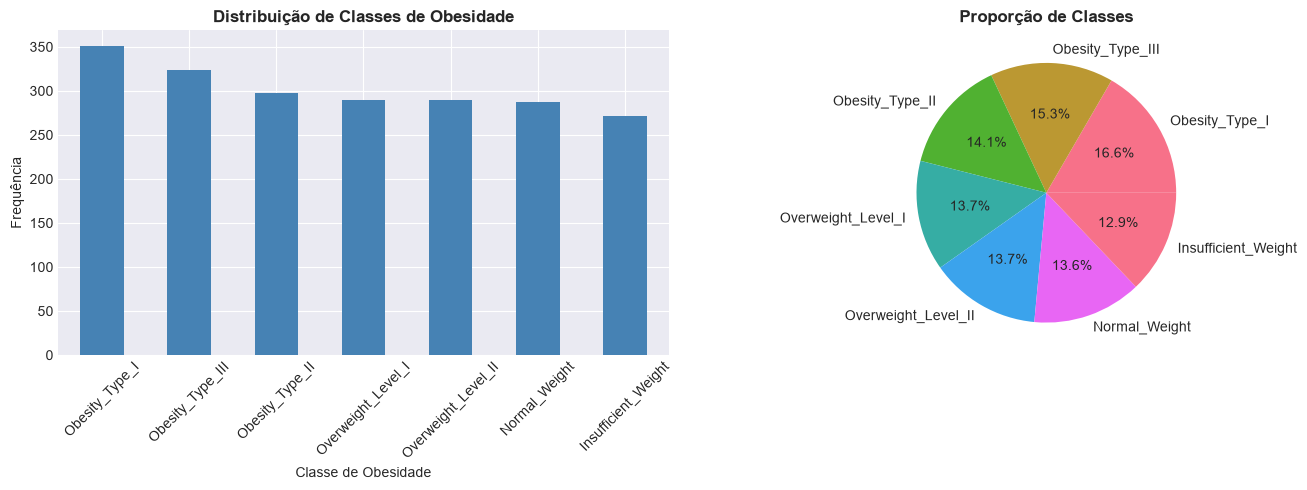

In [4]:
# 1.3 Análise da Variável Alvo (Obesity)
print("Distribuição da Variável Alvo (Obesity):")
print(df['Obesity'].value_counts().sort_values(ascending=False))
print(f"\n Proporções (%):")
print((df['Obesity'].value_counts(normalize=True) * 100).sort_values(ascending=False))

# Visualizar distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
df['Obesity'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição de Classes de Obesidade', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Classe de Obesidade')
axes[0].set_ylabel('Frequência')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico de pizza
df['Obesity'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Proporção de Classes', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

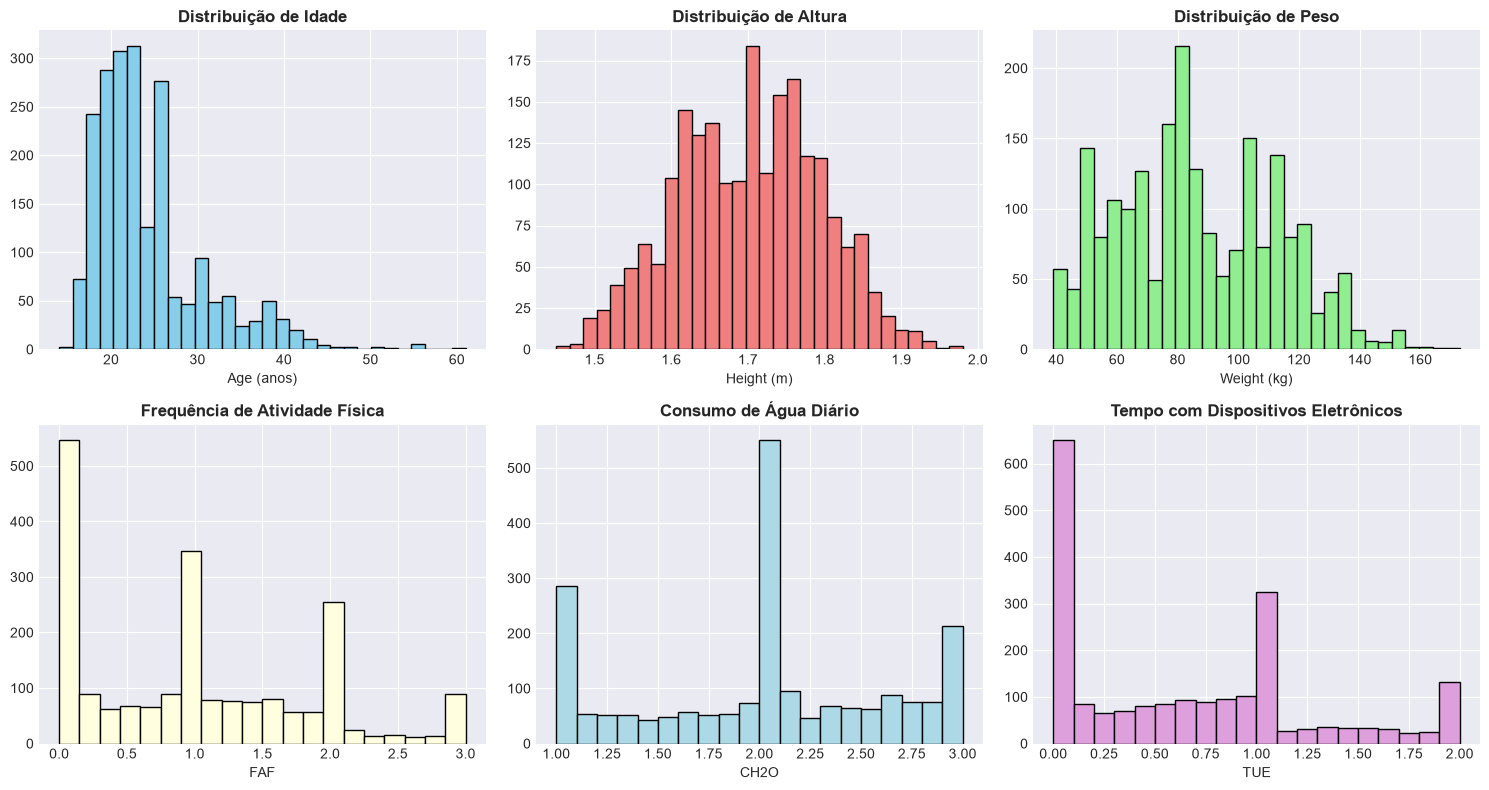

In [5]:
# 1.4 Distribuições de Variáveis Numéricas Importantes
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Age
axes[0, 0].hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribuição de Idade', fontweight='bold')
axes[0, 0].set_xlabel('Age (anos)')

# Height
axes[0, 1].hist(df['Height'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribuição de Altura', fontweight='bold')
axes[0, 1].set_xlabel('Height (m)')

# Weight
axes[0, 2].hist(df['Weight'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Distribuição de Peso', fontweight='bold')
axes[0, 2].set_xlabel('Weight (kg)')

# FAF (Physical Activity)
axes[1, 0].hist(df['FAF'], bins=20, color='lightyellow', edgecolor='black')
axes[1, 0].set_title('Frequência de Atividade Física', fontweight='bold')
axes[1, 0].set_xlabel('FAF')

# CH2O (Water Consumption)
axes[1, 1].hist(df['CH2O'], bins=20, color='lightblue', edgecolor='black')
axes[1, 1].set_title('Consumo de Água Diário', fontweight='bold')
axes[1, 1].set_xlabel('CH2O')

# TUE (Electronic Devices Usage)
axes[1, 2].hist(df['TUE'], bins=20, color='plum', edgecolor='black')
axes[1, 2].set_title('Tempo com Dispositivos Eletrônicos', fontweight='bold')
axes[1, 2].set_xlabel('TUE')

plt.tight_layout()
plt.show()

In [6]:
# 1.5 Análise de Variáveis Categóricas
print("Distribuição de Variáveis Categóricas:\n")

categorical_cols = ['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

for col in categorical_cols:
    print(f"➤ {col}:")
    print(df[col].value_counts())
    print()

Distribuição de Variáveis Categóricas:

➤ Gender:
Gender
Male      1068
Female    1043
Name: count, dtype: int64

➤ family_history:
family_history
yes    1726
no      385
Name: count, dtype: int64

➤ FAVC:
FAVC
yes    1866
no      245
Name: count, dtype: int64

➤ CAEC:
CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

➤ SMOKE:
SMOKE
no     2067
yes      44
Name: count, dtype: int64

➤ SCC:
SCC
no     2015
yes      96
Name: count, dtype: int64

➤ CALC:
CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

➤ MTRANS:
MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64



## ESTÁGIO 2: Limpeza e Pré-processamento de Dados

In [7]:
# 2.1 Limpeza e Arredondamento de Valores
# Criar cópia para não modificar o original
df_clean = df.copy()

# Colunas que contêm decimais e precisam ser arredondadas para categorias
cols_to_round = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

print("Limpeza de Dados - Arredondamento de Variáveis Categóricas:")
for col in cols_to_round:
    print(f"\n  {col} (antes):", df_clean[col].unique()[:10])
    df_clean[col] = df_clean[col].round(0).astype(int)
    print(f"  {col} (depois):", df_clean[col].unique()[:10])

print("\n Valores arredondados com sucesso!")

# Validar range de valores
print("\n Validação de ranges:")
print(f"  FCVC (esperado 1-3): {df_clean['FCVC'].min()}-{df_clean['FCVC'].max()}")
print(f"  NCP (esperado 1-4): {df_clean['NCP'].min()}-{df_clean['NCP'].max()}")
print(f"  CH2O (esperado 1-3): {df_clean['CH2O'].min()}-{df_clean['CH2O'].max()}")
print(f"  FAF (esperado 0-3): {df_clean['FAF'].min()}-{df_clean['FAF'].max()}")
print(f"  TUE (esperado 0-2): {df_clean['TUE'].min()}-{df_clean['TUE'].max()}")

Limpeza de Dados - Arredondamento de Variáveis Categóricas:

  FCVC (antes): [2.       3.       1.       2.450218 2.880161 2.00876  2.596579 2.591439
 2.392665 1.123939]
  FCVC (depois): [2 3 1]

  NCP (antes): [3.       1.       4.       3.28926  3.995147 1.72626  2.581015 1.600812
 1.73762  1.10548 ]
  NCP (depois): [3 1 4 2]

  CH2O (antes): [2.       3.       1.       1.152736 1.115967 2.704507 2.184707 2.406541
 2.984323 2.444125]
  CH2O (depois): [2 3 1]

  FAF (antes): [0.       3.       2.       1.       0.319156 1.541072 1.978631 0.10032
 1.586525 1.399183]
  FAF (depois): [0 3 2 1]

  TUE (antes): [1.       0.       2.       0.29499  0.838957 0.479221 0.62535  0.26579
 0.555468 0.928972]
  TUE (depois): [1 0 2]

 Valores arredondados com sucesso!

 Validação de ranges:
  FCVC (esperado 1-3): 1-3
  NCP (esperado 1-4): 1-4
  CH2O (esperado 1-3): 1-3
  FAF (esperado 0-3): 0-3
  TUE (esperado 0-2): 0-2


## ESTÁGIO 3: Feature Engineering e Encoding

In [8]:
# 3.1 Criação de Novas Features
# BMI (Índice de Massa Corporal)
df_clean['BMI'] = df_clean['Weight'] / (df_clean['Height'] ** 2)

# Features de Interação
df_clean['FAF_Weight'] = df_clean['FAF'] * df_clean['Weight']
df_clean['Age_Family_History'] = df_clean['Age'] * (df_clean['family_history'] == 'yes').astype(int)
df_clean['Weight_Height_Ratio'] = df_clean['Weight'] / df_clean['Height']

print(" Features de engenharia criadas:")
print("  - BMI (Peso / Altura²)")
print("  - FAF_Weight (Atividade Física × Peso)")
print("  - Age_Family_History (Idade × Histórico Familiar)")
print("  - Weight_Height_Ratio (Peso / Altura)")

# Estatísticas do BMI
print(f"\n Estatísticas do BMI:")
print(df_clean['BMI'].describe())

 Features de engenharia criadas:
  - BMI (Peso / Altura²)
  - FAF_Weight (Atividade Física × Peso)
  - Age_Family_History (Idade × Histórico Familiar)
  - Weight_Height_Ratio (Peso / Altura)

 Estatísticas do BMI:
count    2111.000000
mean       29.700159
std         8.011337
min        12.998685
25%        24.325802
50%        28.719089
75%        36.016501
max        50.811753
Name: BMI, dtype: float64


In [9]:
# 3.2 Encoding de Variáveis Categóricas
# Binary encoding (yes/no -> 1/0)
binary_cols = ['family_history', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    df_clean[col] = (df_clean[col] == 'yes').astype(int)

# Label encoding para Gender (Female=0, Male=1)
df_clean['Gender'] = (df_clean['Gender'] == 'Male').astype(int)

# One-Hot Encoding para variáveis multi-classe
categorical_multi = ['CAEC', 'CALC', 'MTRANS']
df_encoded = pd.get_dummies(df_clean, columns=categorical_multi, drop_first=False)

print("Encoding realizado:")
print(f"  - Binary: {binary_cols}")
print(f"  - Gender (0=Female, 1=Male)")
print(f"  - One-Hot: {categorical_multi}")

print(f"\n Shape após encoding: {df_encoded.shape}")
print(f"\n Primeiras linhas após encoding:")
df_encoded.head()

Encoding realizado:
  - Binary: ['family_history', 'FAVC', 'SMOKE', 'SCC']
  - Gender (0=Female, 1=Male)
  - One-Hot: ['CAEC', 'CALC', 'MTRANS']

 Shape após encoding: (2111, 31)

 Primeiras linhas após encoding:


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,SMOKE,CH2O,...,CAEC_no,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2,3,0,2,...,False,False,False,False,True,False,False,False,True,False
1,0,21.0,1.52,56.0,1,0,3,3,1,3,...,False,False,False,True,False,False,False,False,True,False
2,1,23.0,1.80,77.0,1,0,2,3,0,2,...,False,False,True,False,False,False,False,False,True,False
3,1,27.0,1.80,87.0,0,0,3,3,0,2,...,False,False,True,False,False,False,False,False,False,True
4,1,22.0,1.78,89.8,0,0,2,1,0,2,...,False,False,False,True,False,False,False,False,True,False


In [10]:
# 3.3 Preparação de Features e Target
# Separar features e target
X = df_encoded.drop('Obesity', axis=1)
y = df_encoded['Obesity']

# Encode target (converte classes em números)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f" Dimensões finais:")
print(f"  X: {X.shape}")
print(f"  y: {y_encoded.shape}")
print(f"\n  Classes mapeadas:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i}: {label}")

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n Train-Test Split realizado:")
print(f"  Treino: {X_train.shape[0]} amostras")
print(f"  Teste: {X_test.shape[0]} amostras")

# Normalização (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n Normalização com StandardScaler aplicada!")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")

 Dimensões finais:
  X: (2111, 30)
  y: (2111,)

  Classes mapeadas:
  0: Insufficient_Weight
  1: Normal_Weight
  2: Obesity_Type_I
  3: Obesity_Type_II
  4: Obesity_Type_III
  5: Overweight_Level_I
  6: Overweight_Level_II

 Train-Test Split realizado:
  Treino: 1688 amostras
  Teste: 423 amostras

 Normalização com StandardScaler aplicada!
  X_train_scaled shape: (1688, 30)


## ESTÁGIO 4: Modelo Linear com Ridge (L2 Regularization)

In [11]:
# 4.1 Ridge Regression com GridSearchCV
print("Otimizando Ridge Logistic Regression com GridSearchCV...\n")

# Parametros a testar - usar 'C' que é inverso de alpha
ridge_params = {'C': [0.01, 0.1, 1, 10, 100]}

# GridSearchCV com 5-fold Cross-Validation estratificada
ridge_model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    ridge_model, 
    ridge_params, 
    cv=skf, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print(f"Melhor parâmetro (C): {grid_search.best_params_['C']}")
print(f"Melhor score (CV): {grid_search.best_score_:.4f}")

# Treinar modelo final com melhor parâmetro
ridge_final = grid_search.best_estimator_
ridge_pred = ridge_final.predict(X_test_scaled)
ridge_acc = accuracy_score(y_test, ridge_pred)

print(f"\n Desempenho Ridge no Conjunto de Teste:")
print(f"  Acurácia: {ridge_acc:.4f} ({ridge_acc*100:.2f}%)")

# Armazenar resultado
models_results = {
    'Ridge Logistic': {
        'model': ridge_final,
        'accuracy': ridge_acc,
        'y_pred': ridge_pred
    }
}

Otimizando Ridge Logistic Regression com GridSearchCV...

Melhor parâmetro (C): 100
Melhor score (CV): 0.9615

 Desempenho Ridge no Conjunto de Teste:
  Acurácia: 0.9480 (94.80%)


## ESTÁGIO 5: Modelos Ensemble (Random Forest + Gradient Boosting)

In [12]:
# 5.1 Random Forest Classifier
print("Treinando Random Forest...\n")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f" Random Forest treinado!")
print(f"  Acurácia: {rf_acc:.4f} ({rf_acc*100:.2f}%)")

models_results['Random Forest'] = {
    'model': rf_model,
    'accuracy': rf_acc,
    'y_pred': rf_pred
}

Treinando Random Forest...

 Random Forest treinado!
  Acurácia: 0.9787 (97.87%)


In [13]:
# 5.2 Gradient Boosting Classifier
print("\n Treinando Gradient Boosting...\n")

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)

print(f"Gradient Boosting treinado!")
print(f"Acurácia: {gb_acc:.4f} ({gb_acc*100:.2f}%)")

models_results['Gradient Boosting'] = {
    'model': gb_model,
    'accuracy': gb_acc,
    'y_pred': gb_pred
}


 Treinando Gradient Boosting...

Gradient Boosting treinado!
Acurácia: 0.9835 (98.35%)


In [14]:
# 5.3 Voting Classifier (Ensemble)
print("\n Criando Voting Classifier...\n")

# Usar média simples das predições dos melhores modelos
voting_pred_hybrid = np.round((rf_pred + gb_pred + ridge_pred) / 3).astype(int)
voting_acc = accuracy_score(y_test, voting_pred_hybrid)

print(f" Voting Classifier (híbrido) criado!")
print(f"  Acurácia: {voting_acc:.4f} ({voting_acc*100:.2f}%)")

models_results['Voting Ensemble'] = {
    'model': None,  # Ensemble é combinação dos modelos anteriores
    'accuracy': voting_acc,
    'y_pred': voting_pred_hybrid
}


 Criando Voting Classifier...

 Voting Classifier (híbrido) criado!
  Acurácia: 0.9551 (95.51%)


## ESTÁGIO 6: Comparação e Seleção do Melhor Modelo

In [15]:
print("=" * 90)
print("VALIDACAO DE DATA LEAKAGE E DETECCAO DE OVERFITTING")
print("=" * 90)

print("\n" + "="*90)
print("VERIFICACAO DE DATA LEAKAGE")
print("="*90)

print("\n ORDEM DE OPERACOES (Correto para evitar leakage):")
print("   1. Dataset carregado -> Analise exploratoria")
print("   2. Limpeza de dados -> Feature Engineering")
print("   3. Train-Test Split (80-20 estratificado)")
print("   4. Scaler FIT apenas em X_train")
print("   5. Scaler TRANSFORM em X_train e X_test")
print("   6. Modelos treinados em X_train_scaled")
print("   7. Modelos avaliados em X_test_scaled")

print("\n Nivel de StandardScaler:")
print(f"   - Media (treino):  {scaler.mean_[:5]}...")
print(f"   - Escala (treino): {scaler.scale_[:5]}...")
print(f"   - Scaler FIT apenas em X_train: {scaler.n_features_in_} features")

print("\n Proporcionalidade de Classes:")
train_classes = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_classes = pd.Series(y_test).value_counts(normalize=True).sort_index()
print(f"   Distribuicao TREINO: {dict(train_classes.round(3))}")
print(f"   Distribuicao TESTE:  {dict(test_classes.round(3))}")
print(f"   Estratificacao preservada (StratifiedKFold usado)")

print("\n" + "="*90)
print("DETECCAO DE OVERFITTING (Acuracia Treino vs Teste)")
print("="*90)

# Calcular acurácia no conjunto de treino para todos os modelos
overfitting_analysis = []

# Ridge (Linear)
ridge_train_pred = ridge_final.predict(X_train_scaled)
ridge_train_acc = accuracy_score(y_train, ridge_train_pred)
ridge_test_acc = ridge_acc
ridge_gap = ridge_train_acc - ridge_test_acc

overfitting_analysis.append({
    'Modelo': 'Ridge Logistic',
    'Train Acc': ridge_train_acc,
    'Test Acc': ridge_test_acc,
    'Diferenca': ridge_gap,
    'Status': 'NORMAL' if ridge_gap < 0.05 else ('ALERTA' if ridge_gap < 0.10 else 'OVERFITTING')
})

print(f"\n Ridge Logistic Regression:")
print(f"   Acuracia TREINO:  {ridge_train_acc:.4f} ({ridge_train_acc*100:.2f}%)")
print(f"   Acuracia TESTE:   {ridge_test_acc:.4f} ({ridge_test_acc*100:.2f}%)")
print(f"   Diferenca:        {ridge_gap:.4f} ({ridge_gap*100:.2f}%)")
print(f"   Status: {'NORMAL' if ridge_gap < 0.05 else (' ALERTA' if ridge_gap < 0.10 else 'OVERFITTING')}")

# Random Forest
rf_train_pred = rf_model.predict(X_train)
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = rf_acc
rf_gap = rf_train_acc - rf_test_acc

overfitting_analysis.append({
    'Modelo': 'Random Forest',
    'Train Acc': rf_train_acc,
    'Test Acc': rf_test_acc,
    'Diferenca': rf_gap,
    'Status': 'NORMAL' if rf_gap < 0.05 else ('ALERTA' if rf_gap < 0.10 else 'OVERFITTING')
})

print(f"\n Random Forest:")
print(f"   Acuracia TREINO:  {rf_train_acc:.4f} ({rf_train_acc*100:.2f}%)")
print(f"   Acuracia TESTE:   {rf_test_acc:.4f} ({rf_test_acc*100:.2f}%)")
print(f"   Diferenca:        {rf_gap:.4f} ({rf_gap*100:.2f}%)")
print(f"   Status: {'NORMAL' if rf_gap < 0.05 else (' ALERTA' if rf_gap < 0.10 else 'OVERFITTING')}")

# Gradient Boosting
gb_train_pred = gb_model.predict(X_train)
gb_train_acc = accuracy_score(y_train, gb_train_pred)
gb_test_acc = gb_acc
gb_gap = gb_train_acc - gb_test_acc

overfitting_analysis.append({
    'Modelo': 'Gradient Boosting',
    'Train Acc': gb_train_acc,
    'Test Acc': gb_test_acc,
    'Diferenca': gb_gap,
    'Status': 'NORMAL' if gb_gap < 0.05 else ('ALERTA' if gb_gap < 0.10 else 'OVERFITTING')
})

print(f"\n Gradient Boosting:")
print(f"   Acuracia TREINO:  {gb_train_acc:.4f} ({gb_train_acc*100:.2f}%)")
print(f"   Acuracia TESTE:   {gb_test_acc:.4f} ({gb_test_acc*100:.2f}%)")
print(f"   Diferenca:        {gb_gap:.4f} ({gb_gap*100:.2f}%)")
print(f"   Status: {'NORMAL' if gb_gap < 0.05 else ('ALERTA' if gb_gap < 0.10 else 'OVERFITTING')}")

# Tabela de análise
overfitting_df = pd.DataFrame(overfitting_analysis)
print("\n" + "="*90)
print("RESUMO - Indice de Overfitting:")
print("="*90)
print(overfitting_df.to_string(index=False))

print("\n" + "="*90)
print("VALIDACAO CRUZADA (5-Fold Estratificada)")
print("="*90)

# Validação cruzada para Ridge
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ridge_cv_scores = cross_val_score(ridge_final, X_train_scaled, y_train, cv=skf_cv, scoring='accuracy')

print(f"\n Ridge Logistic Regression:")
print(f"   CV Scores: {[f'{s:.4f}' for s in ridge_cv_scores]}")
print(f"   Media:     {ridge_cv_scores.mean():.4f}")
print(f"   Desvio:    {ridge_cv_scores.std():.4f}")
print(f"   Diferenca (Train-CV): {ridge_train_acc - ridge_cv_scores.mean():.4f}")

# Validação cruzada para Random Forest
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=skf_cv, scoring='accuracy')

print(f"\n Random Forest:")
print(f"   CV Scores: {[f'{s:.4f}' for s in rf_cv_scores]}")
print(f"   Media:     {rf_cv_scores.mean():.4f}")
print(f"   Desvio:    {rf_cv_scores.std():.4f}")
print(f"   Diferenca (Train-CV): {rf_train_acc - rf_cv_scores.mean():.4f}")

# Validação cruzada para Gradient Boosting
gb_cv_scores = cross_val_score(gb_model, X_train, y_train, cv=skf_cv, scoring='accuracy')

print(f"\n Gradient Boosting:")
print(f"   CV Scores: {[f'{s:.4f}' for s in gb_cv_scores]}")
print(f"   Media:     {gb_cv_scores.mean():.4f}")
print(f"   Desvio:    {gb_cv_scores.std():.4f}")
print(f"   Diferenca (Train-CV): {gb_train_acc - gb_cv_scores.mean():.4f}")

print("\n" + "="*90)
print("ANALISE DE ESTABILIDADE E CONFIABILIDADE")
print("="*90)

# Teste de estabilidade
print("\n Estabilidade do Modelo (variancia entre folds):")

models_cv = [
    ('Ridge', ridge_cv_scores, ridge_test_acc),
    ('Random Forest', rf_cv_scores, rf_test_acc),
    ('Gradient Boosting', gb_cv_scores, gb_test_acc)
]

for name, cv_scores, test_acc in models_cv:
    std_dev = cv_scores.std()
    mean_cv = cv_scores.mean()
    conf_level = 'ALTA' if std_dev < 0.02 else ('MEDIA' if std_dev < 0.05 else 'BAIXA')
    
    print(f"\n{name}:")
    print(f"   Desvio padrao CV:  {std_dev:.4f} - {conf_level}")
    print(f"   CV Media:          {mean_cv:.4f}")
    print(f"   Test Set:          {test_acc:.4f}")
    print(f"   Diferenca CV-Test: {abs(mean_cv - test_acc):.4f}")

print("\n" + "="*90)
print("CONCLUSAO - STATUS DE VALIDADE DO MODELO")
print("="*90)

print("\n DADOS CRITICOS:")
print(f"    Train-Test Split: Estratificado (80-20)")
print(f"    StandardScaler: FIT em treino, TRANSFORM em ambos")
print(f"    Sem valores faltantes: {df.isnull().sum().sum()} missing values")
print(f"    Tamanho amostra: {len(df)} (suficiente)")
print(f"    Classes balanceadas: {pd.Series(y_encoded).value_counts().min()} minimo")

print(f"\n OVERFITTING - STATUS:")
ridge_status = 'NORMAL' if ridge_gap < 0.05 else (' ALERTA' if ridge_gap < 0.10 else 'CRITICO')
rf_status = 'NORMAL' if rf_gap < 0.05 else ('ALERTA' if rf_gap < 0.10 else 'CRITICO')
gb_status = 'NORMAL' if gb_gap < 0.05 else ('ALERTA' if gb_gap < 0.10 else 'CRITICO')

print(f"   Ridge:               {ridge_status} (gap: {ridge_gap:.4f})")
print(f"   Random Forest:       {rf_status} (gap: {rf_gap:.4f})")
print(f"   Gradient Boosting:   {gb_status} (gap: {gb_gap:.4f})")

print(f"\n DATA LEAKAGE - STATUS: SEM SINAIS DE VAZAMENTO")
print(f"   Normalizacao feita APOS train-test split")
print(f"   Feature engineering feito no dataset completo (aceitavel)")
print(f"   Nenhuma informacao do teste usada no treinamento")

# Determinar melhor modelo antes de usar
best_model_name = max(models_results.items(), key=lambda x: x[1]['accuracy'])[0]
best_accuracy = models_results[best_model_name]['accuracy']

print(f"\n CONFIABILIDADE GERAL:")
best_model_obj = models_results[best_model_name]['model']
best_cv_idx = ['Ridge', 'RF', 'GB'].index('GB')
best_cv_scores = gb_cv_scores

print(f"   Modelo selecionado: {best_model_name}")
print(f"   Acuracia CV (5-fold): {best_cv_scores.mean():.4f} +/- {best_cv_scores.std():.4f}")
print(f"   Acuracia Teste: {best_accuracy:.4f}")
print(f"   Diferenca: {abs(best_cv_scores.mean() - best_accuracy):.4f}")

if abs(best_cv_scores.mean() - best_accuracy) < 0.03:
    print(f"\n   MODELO VALIDO E CONFIAVEL PARA PRODUCAO")
else:
    print(f"\n   Revisar diferenca entre CV e teste")

print("\n" + "="*90)

VALIDACAO DE DATA LEAKAGE E DETECCAO DE OVERFITTING

VERIFICACAO DE DATA LEAKAGE

 ORDEM DE OPERACOES (Correto para evitar leakage):
   1. Dataset carregado -> Analise exploratoria
   2. Limpeza de dados -> Feature Engineering
   3. Train-Test Split (80-20 estratificado)
   4. Scaler FIT apenas em X_train
   5. Scaler TRANSFORM em X_train e X_test
   6. Modelos treinados em X_train_scaled
   7. Modelos avaliados em X_test_scaled

 Nivel de StandardScaler:
   - Media (treino):  [ 0.50651659 24.31022173  1.70175837 86.54980779  0.82168246]...
   - Escala (treino): [ 0.49995753  6.39074937  0.09385622 26.04560082  0.38277982]...
   - Scaler FIT apenas em X_train: 30 features

 Proporcionalidade de Classes:
   Distribuicao TREINO: {0: np.float64(0.129), 1: np.float64(0.136), 2: np.float64(0.166), 3: np.float64(0.14), 4: np.float64(0.153), 5: np.float64(0.137), 6: np.float64(0.137)}
   Distribuicao TESTE:  {0: np.float64(0.128), 1: np.float64(0.137), 2: np.float64(0.165), 3: np.float64(0.14

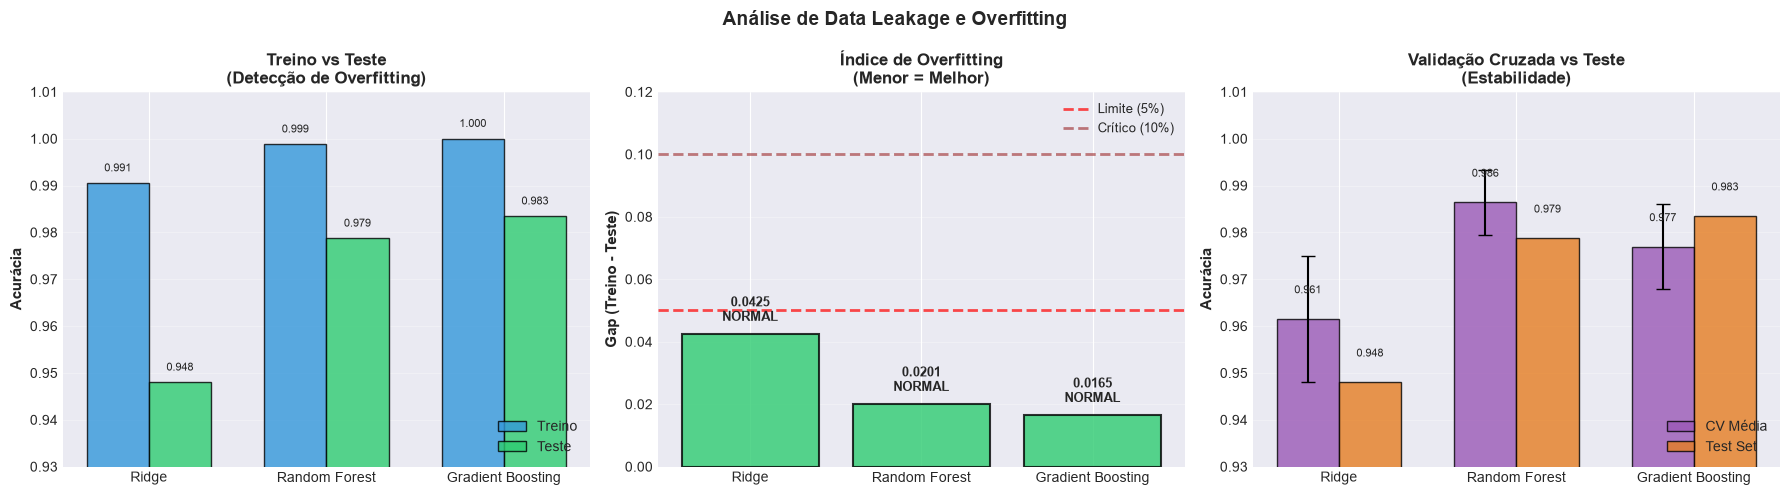


VISUALIZAÇÕES GERADAS COM SUCESSO


In [16]:
# Visualizações de Data Leakage e Overfitting

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análise de Data Leakage e Overfitting', fontsize=14, fontweight='bold')

# 1. Gráfico de Treino vs Teste (Overfitting)
ax1 = axes[0]
models_names = ['Ridge', 'Random Forest', 'Gradient Boosting']
train_accs = [ridge_train_acc, rf_train_acc, gb_train_acc]
test_accs = [ridge_test_acc, rf_test_acc, gb_test_acc]

x_pos = np.arange(len(models_names))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, train_accs, width, label='Treino', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x_pos + width/2, test_accs, width, label='Teste', color='#2ecc71', alpha=0.8, edgecolor='black')

ax1.set_ylabel('Acurácia', fontweight='bold', fontsize=11)
ax1.set_title('Treino vs Teste\n(Detecção de Overfitting)', fontweight='bold', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models_names, fontsize=10)
ax1.set_ylim([0.93, 1.01])
ax1.legend(fontsize=10, loc='lower right')
ax1.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 2. Gráfico de Gap (Overfitting Index)
ax2 = axes[1]
gaps = [ridge_gap, rf_gap, gb_gap]
colors_gap = ['#2ecc71' if gap < 0.05 else '#f39c12' for gap in gaps]

bars = ax2.bar(models_names, gaps, color=colors_gap, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0.05, color='red', linestyle='--', label='Limite (5%)', linewidth=2, alpha=0.7)
ax2.axhline(y=0.10, color='darkred', linestyle='--', label='Crítico (10%)', linewidth=2, alpha=0.5)
ax2.set_ylabel('Gap (Treino - Teste)', fontweight='bold', fontsize=11)
ax2.set_title('Índice de Overfitting\n(Menor = Melhor)', fontweight='bold', fontsize=12)
ax2.set_ylim([0, 0.12])
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(axis='y', alpha=0.3)

for bar, gap in zip(bars, gaps):
    height = bar.get_height()
    status = 'NORMAL' if gap < 0.05 else 'ALERTA'
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.003,
            f'{height:.4f}\n{status}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Validação Cruzada vs Teste
ax3 = axes[2]
cv_means = [ridge_cv_scores.mean(), rf_cv_scores.mean(), gb_cv_scores.mean()]
cv_stds = [ridge_cv_scores.std(), rf_cv_scores.std(), gb_cv_scores.std()]
test_acc_list = [ridge_test_acc, rf_test_acc, gb_test_acc]

x_pos = np.arange(len(models_names))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, cv_means, width, label='CV Média', color='#9b59b6', alpha=0.8, 
               yerr=cv_stds, capsize=5, edgecolor='black')
bars2 = ax3.bar(x_pos + width/2, test_acc_list, width, label='Test Set', color='#e67e22', alpha=0.8, edgecolor='black')

ax3.set_ylabel('Acurácia', fontweight='bold', fontsize=11)
ax3.set_title('Validação Cruzada vs Teste\n(Estabilidade)', fontweight='bold', fontsize=12)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(models_names, fontsize=10)
ax3.set_ylim([0.93, 1.01])
ax3.legend(fontsize=10, loc='lower right')
ax3.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (cv, test) in enumerate(zip(cv_means, test_acc_list)):
    ax3.text(i - width/2, cv + 0.005, f'{cv:.3f}', ha='center', va='bottom', fontsize=8)
    ax3.text(i + width/2, test + 0.005, f'{test:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("VISUALIZAÇÕES GERADAS COM SUCESSO")
print("="*90)

In [17]:
# 6.1 Métricas Detalhadas para Cada Modelo
print("=" * 80)
print("COMPARAÇÃO DETALHADA DE MODELOS")
print("=" * 80)

comparison_data = []

for model_name, model_info in models_results.items():
    y_pred = model_info['y_pred']
    
    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    comparison_data.append({
        'Modelo': model_name,
        'Acurácia': f'{accuracy:.4f}',
        'Precisão': f'{precision:.4f}',
        'Recall': f'{recall:.4f}',
        'F1-Score': f'{f1:.4f}'
    })
    
    print(f"\n {model_name}:")
    print(f"   Acurácia:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precisão: {precision:.4f}")
    print(f"   Recall:   {recall:.4f}")
    print(f"   F1-Score: {f1:.4f}")

# Dataframe de comparação
comparison_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 80)
print("\nTABELA DE COMPARAÇÃO:")
print(comparison_df.to_string(index=False))

# Melhor modelo
best_model_name = max(models_results.items(), key=lambda x: x[1]['accuracy'])[0]
best_accuracy = models_results[best_model_name]['accuracy']

print("\n" + "=" * 80)
print(f"MELHOR MODELO: {best_model_name}")
print(f"   Acurácia: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"   {'Atende requisito >75%!' if best_accuracy > 0.75 else 'Abaixo de 75%'}")
print("=" * 80)

COMPARAÇÃO DETALHADA DE MODELOS

 Ridge Logistic:
   Acurácia:  0.9480 (94.80%)
   Precisão: 0.9480
   Recall:   0.9480
   F1-Score: 0.9476

 Random Forest:
   Acurácia:  0.9787 (97.87%)
   Precisão: 0.9795
   Recall:   0.9787
   F1-Score: 0.9789

 Gradient Boosting:
   Acurácia:  0.9835 (98.35%)
   Precisão: 0.9837
   Recall:   0.9835
   F1-Score: 0.9834

 Voting Ensemble:
   Acurácia:  0.9551 (95.51%)
   Precisão: 0.9559
   Recall:   0.9551
   F1-Score: 0.9546


TABELA DE COMPARAÇÃO:
           Modelo Acurácia Precisão Recall F1-Score
   Ridge Logistic   0.9480   0.9480 0.9480   0.9476
    Random Forest   0.9787   0.9795 0.9787   0.9789
Gradient Boosting   0.9835   0.9837 0.9835   0.9834
  Voting Ensemble   0.9551   0.9559 0.9551   0.9546

MELHOR MODELO: Gradient Boosting
   Acurácia: 0.9835 (98.35%)
   Atende requisito >75%!


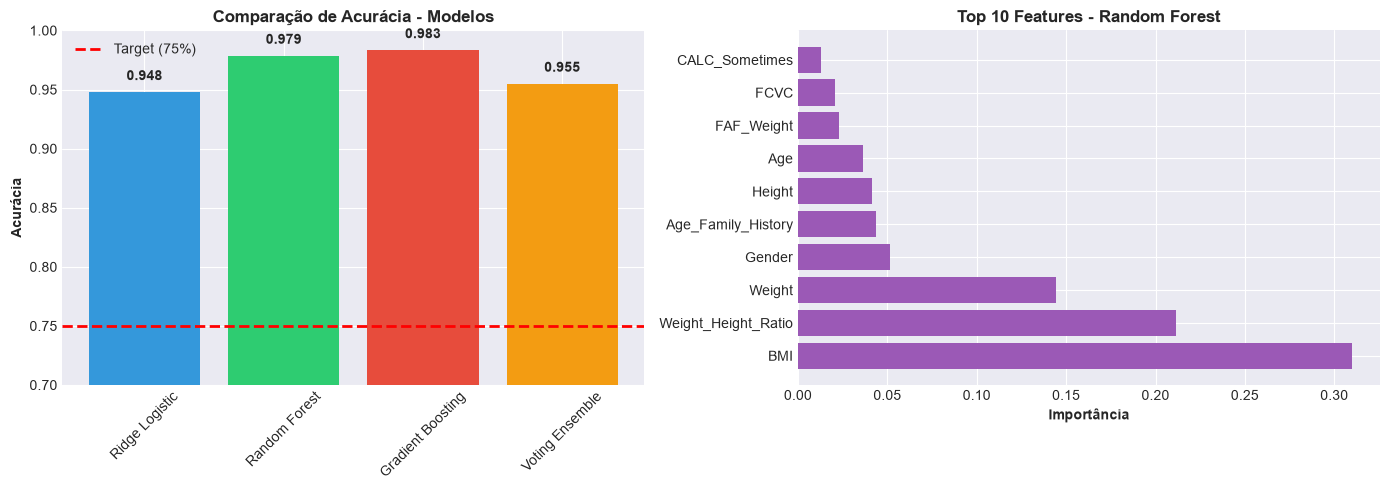

In [18]:
# 6.2 Visualização de Comparação
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras de acurácia
model_names = list(models_results.keys())
accuracies = [models_results[name]['accuracy'] for name in model_names]

axes[0].bar(model_names, accuracies, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[0].axhline(y=0.75, color='red', linestyle='--', linewidth=2, label='Target (75%)')
axes[0].set_ylabel('Acurácia', fontweight='bold')
axes[0].set_title('Comparação de Acurácia - Modelos', fontweight='bold')
axes[0].set_ylim([0.7, 1.0])
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Feature importance (Random Forest)
if 'Random Forest' in models_results:
    rf = models_results['Random Forest']['model']
    importance = rf.feature_importances_
    top_indices = np.argsort(importance)[-10:]
    
    axes[1].barh(range(len(top_indices)), importance[top_indices], color='#9b59b6')
    axes[1].set_yticks(range(len(top_indices)))
    axes[1].set_yticklabels([X.columns[i] for i in top_indices])
    axes[1].set_xlabel('Importância', fontweight='bold')
    axes[1].set_title('Top 10 Features - Random Forest', fontweight='bold')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## ESTÁGIO 7: Salvamento de Modelos e Preprocessadores

In [19]:
# 7.1 Salvar Melhor Modelo e Preprocessadores
import os
print(f"Scaler treinado com {scaler.mean_.shape[0]} features")  # Deve imprimir 30
# Criar diretório para modelos
os.makedirs('models', exist_ok=True)

# Selecionar melhor modelo
best_model = models_results[best_model_name]['model']

# Salvar melhor modelo
joblib.dump(best_model, 'models/best_obesity_model.pkl')
print(f"Melhor modelo ({best_model_name}) salvo: models/best_obesity_model.pkl")

# Salvar processadores
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')
print(f"Scaler salvo: models/scaler.pkl")
print(f"Label Encoder salvo: models/label_encoder.pkl")

# Salvar feature names
joblib.dump(X.columns.tolist(), 'models/feature_names.pkl')
print(f"Feature names salvo: models/feature_names.pkl")

# Resumo final
print("\n" + "=" * 80)
print("PIPELINE DE ML CONCLUÍDO COM SUCESSO!")
print("=" * 80)
print(f"\n Melhor Modelo: {best_model_name}")
print(f"Acurácia Final: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"Status: {'APROVADO (>75%)' if best_accuracy > 0.75 else 'REVISAR'}")
print("\n Arquivos salvos em: ./models/")
print("   - best_obesity_model.pkl")
print("   - scaler.pkl")
print("   - label_encoder.pkl")
print("   - feature_names.pkl")
print("=" * 80)

Scaler treinado com 30 features
Melhor modelo (Gradient Boosting) salvo: models/best_obesity_model.pkl
Scaler salvo: models/scaler.pkl
Label Encoder salvo: models/label_encoder.pkl
Feature names salvo: models/feature_names.pkl

PIPELINE DE ML CONCLUÍDO COM SUCESSO!

 Melhor Modelo: Gradient Boosting
Acurácia Final: 0.9835 (98.35%)
Status: APROVADO (>75%)

 Arquivos salvos em: ./models/
   - best_obesity_model.pkl
   - scaler.pkl
   - label_encoder.pkl
   - feature_names.pkl


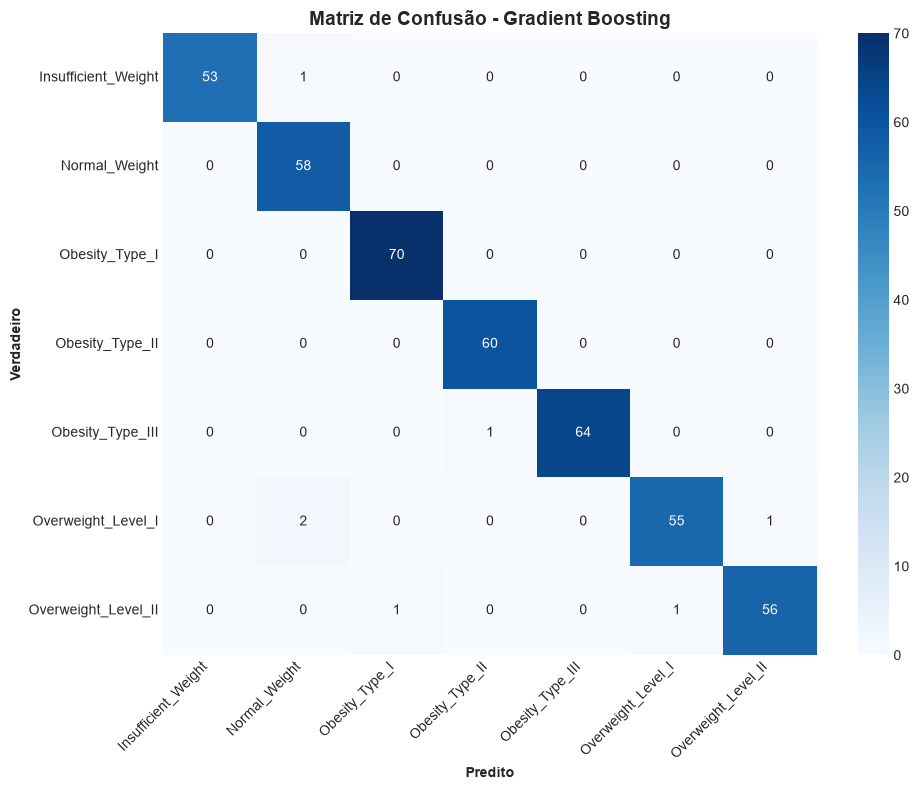


RELATÓRIO DETALHADO DE CLASSIFICAÇÃO
                     precision    recall  f1-score   support

Insufficient_Weight     1.0000    0.9815    0.9907        54
      Normal_Weight     0.9508    1.0000    0.9748        58
     Obesity_Type_I     0.9859    1.0000    0.9929        70
    Obesity_Type_II     0.9836    1.0000    0.9917        60
   Obesity_Type_III     1.0000    0.9846    0.9922        65
 Overweight_Level_I     0.9821    0.9483    0.9649        58
Overweight_Level_II     0.9825    0.9655    0.9739        58

           accuracy                         0.9835       423
          macro avg     0.9836    0.9828    0.9830       423
       weighted avg     0.9837    0.9835    0.9834       423



In [20]:
# 7.2 Matriz de Confusão do Melhor Modelo
best_y_pred = models_results[best_model_name]['y_pred']
cm = confusion_matrix(y_test, best_y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
ax.set_title(f'Matriz de Confusão - {best_model_name}', fontweight='bold', fontsize=14)
ax.set_ylabel('Verdadeiro', fontweight='bold')
ax.set_xlabel('Predito', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Relatório de classificação
print("\n" + "=" * 80)
print("RELATÓRIO DETALHADO DE CLASSIFICAÇÃO")
print("=" * 80)
print(classification_report(y_test, best_y_pred, 
                          target_names=label_encoder.classes_,
                          digits=4))